# Knowledge-graph completion, recommendation, and uncertainty

A knowledge graph stores facts as triples $(h, r, t)$ -- a head entity, a relation, a tail entity. Most
graphs are radically incomplete: the interesting question is which facts are missing. This notebook fits
a knowledge-graph embedding model with mixle's ordinary estimation framework and then uses it to
complete any slot of a fact, recommend the most plausible missing facts and missing subgraphs, and -- the
part that makes a recommendation trustworthy -- attach two kinds of uncertainty to every suggestion:
calibrated conformal prediction sets and epistemic (model-disagreement) uncertainty from an ensemble.

## 1. Fit the knowledge graph with the regular estimation framework

`KnowledgeGraphDistribution` is a `mixle.stats.graph` distribution over triples, fit like any other
mixle model: `optimize(triples, KnowledgeGraphEstimator(num_entities, num_relations, dim=...))`.
It is a DistMult embedding model -- entities and relations get vectors, a fact scores by the bilinear
form $\langle e_h, e_r, e_t\rangle$ -- trained to maximize the completion likelihood in all three
directions (tail, head, relation), so any slot can be filled. Here we generate a synthetic graph from a
known embedding so we can check the recovered completions against the truth.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.stats import KnowledgeGraphEstimator
from mixle.inference.estimation import optimize

rng = np.random.RandomState(0)
nE, nR, d = 40, 6, 16
ent_true = rng.normal(0, 1, (nE, d)); rel_true = rng.normal(0, 1, (nR, d))
def true_tails(h, r, k=5):                                            # a relation can hold several true tails
    return np.argsort(-(ent_true @ (ent_true[h] * rel_true[r])))[:k].tolist()
all_facts = [(h, r, int(t)) for h in range(nE) for r in range(nR) for t in true_tails(h, r)]
rng.shuffle(all_facts)
# the graph is incomplete: we only observe (train + calibration); the rest are genuinely missing true facts
n_tr, n_cal = int(0.6 * len(all_facts)), int(0.2 * len(all_facts))
train, calib, test = all_facts[:n_tr], all_facts[n_tr:n_tr + n_cal], all_facts[n_tr + n_cal:]
observed = train + calib
true_of = {}
for h, r, t in all_facts:
    true_of.setdefault((h, r), set()).add(t)

kg = optimize(train, KnowledgeGraphEstimator(nE, nR, dim=d, epochs=300, lr=1.0, seed=1), max_its=1, rng=rng, print_iter=10**9)
print('fitted a %s on %d observed facts (%d held out as genuinely missing)' % (kg, len(observed), len(test)))
print('held-out tail-completion accuracy (top-1 is a true tail) = %.3f' %
      np.mean([kg.tail_log_posterior(h, r).argmax() in true_of[(h, r)] for h, r, t in test]))

fitted a KnowledgeGraphDistribution(num_entities=40, num_relations=6, dim=16, name=None, keys=None) on 960 observed facts (240 held out as genuinely missing)
held-out tail-completion accuracy (top-1 is a true tail) = 0.867


## 2. Completing any slot of a fact

`complete(h, r, t)` fills the single slot left as `None` and returns a log-posterior over the candidates
for that slot: `complete(h, r)` predicts the tail, `complete(r=r, t=t)` the head, `complete(h=h, t=t)` the
relation. `rank(...)` sorts the candidates, optionally excluding ones already known. Tail and head ask
about entities; relation asks about the (few) relation types.

In [2]:
h, r, t = test[0]
print('query (%d, %d, ?)   top tails    :' % (h, r), [c for c, _ in kg.rank(h=h, r=r, top_n=5)], ' truth', t)
print('query (?, %d, %d)   top heads    :' % (r, t), [c for c, _ in kg.rank(r=r, t=t, top_n=5)], ' truth', h)
print('query (%d, ?, %d)   top relations:' % (h, t), [c for c, _ in kg.rank(h=h, t=t, top_n=3)], ' truth', r)
tail_acc = np.mean([kg.complete(h=h, r=r).argmax() in true_of[(h, r)] for h, r, t in test])
rel_acc = np.mean([kg.complete(h=h, t=t).argmax() == r for h, r, t in test])
print('completion accuracy:  tail top-1 is a true tail = %.3f   relation top-1 correct = %.3f' % (tail_acc, rel_acc))

query (23, 5, ?)   top tails    : [20, 4, 9, 10, 23]  truth 23
query (?, 5, 23)   top heads    : [20, 4, 9, 10, 23]  truth 23
query (23, ?, 23)   top relations: [4, 0, 2]  truth 5
completion accuracy:  tail top-1 is a true tail = 0.867   relation top-1 correct = 0.467


## 3. Recommending missing knowledge

`recommend(known, top_n)` ranks the facts the model finds most plausible that are not already in the
graph: for every observed $(h, r)$ context it scores the unseen tails and returns the global top
suggestions. These are the model's best guesses at missing edges, each with its log-probability as a
confidence score.

In [3]:
missing_true = {(h, r, t) for h, r, t in test}                       # the true facts we held out
recommendations = kg.recommend(observed, top_n=20)
hits = [(h, r, t) in missing_true for h, r, t, _ in recommendations]
print('top recommended missing facts (head, relation, tail, log-prob, is a held-out true fact):')
for (h, r, t, lp), ok in list(zip(recommendations, hits))[:8]:
    print('  (%2d, %d, %2d)   log p = %5.2f   %s' % (h, r, t, lp, 'TRUE' if ok else '-'))
print('precision@20 against the held-out true facts = %.2f (vs %.3f if we guessed at random)' %
      (np.mean(hits), len(missing_true) / (nE * nR * nE)))

top recommended missing facts (head, relation, tail, log-prob, is a held-out true fact):
  (35, 0,  0)   log p = -1.41   TRUE
  (12, 2,  1)   log p = -1.42   TRUE
  ( 6, 0, 10)   log p = -1.50   TRUE
  (25, 3,  2)   log p = -1.51   TRUE
  ( 2, 1, 29)   log p = -1.52   TRUE
  (17, 2, 37)   log p = -1.60   -
  ( 5, 3, 29)   log p = -1.61   TRUE
  (28, 2, 28)   log p = -1.62   -
precision@20 against the held-out true facts = 0.65 (vs 0.025 if we guessed at random)


## 4. Recommending a missing subgraph

`recommend_subgraph(node, known, top_n)` focuses on one entity and proposes the most plausible new edges
touching it, in either direction ($(\text{node}, r, ?)$ and $(?, r, \text{node})$), excluding edges
already present. This is the local view: what is probably missing around this node.

In [4]:
node = 0
edges = kg.recommend_subgraph(node, observed, top_n=6)
print('suggested missing edges around entity %d (marked TRUE if actually held-out true facts):' % node)
for h, r, t, lp in edges:
    print('  %2d --r%d--> %2d   %s' % (h, r, t, 'TRUE' if (h, r, t) in missing_true else '-'))

suggested missing edges around entity 0 (marked TRUE if actually held-out true facts):
  35 --r0-->  0   TRUE
  36 --r2-->  0   -
   0 --r5--> 36   TRUE
  36 --r5-->  0   -
   0 --r4--> 13   -
  13 --r4-->  0   TRUE


## 5. Calibrated uncertainty on completions

A ranked list is not enough for a decision; we want a guarantee. `ConformalKnowledgeGraph` calibrates the
model on held-out true triples and returns, for any slot, a prediction set that contains the true filler
with probability at least $1-\alpha$, distribution-free. The nonconformity is $1 - p(\text{true filler})$,
so a confident model gives a small set and an uncertain one a larger set, with the coverage guarantee
holding either way. We check coverage in all three directions.

In [5]:
from mixle.ppl import ConformalKnowledgeGraph

print('conformal completion sets (alpha = 0.10):')
for slot in ['tail', 'head', 'relation']:
    ck = ConformalKnowledgeGraph(kg, calib, slot=slot, alpha=0.1)
    cov = ck.covers(test).mean(); size = ck.set_sizes(test).mean()
    K = nR if slot == 'relation' else nE
    print('  %-9s coverage = %.3f (target 0.90)   mean set size = %.2f of %d' % (slot, cov, size, K))
# a concrete tail completion set for one query
ck = ConformalKnowledgeGraph(kg, calib, slot='tail', alpha=0.1)
h, r, t = test[0]
cset = ck.completion_set(h=h, r=r)
print('query (%d, %d, ?): conformal tail set has %d of %d candidates; contains the held-out true tail %d? %s' %
      (h, r, cset.size, nE, t, t in cset))

conformal completion sets (alpha = 0.10):
  tail      coverage = 0.887 (target 0.90)   mean set size = 14.23 of 40
  head      coverage = 0.900 (target 0.90)   mean set size = 15.45 of 40
  relation  coverage = 0.900 (target 0.90)   mean set size = 2.81 of 6
query (23, 5, ?): conformal tail set has 17 of 40 candidates; contains the held-out true tail 23? True


## 6. Epistemic uncertainty: which recommendations to trust

The conformal set captures one fitted model's uncertainty. Epistemic uncertainty asks how much the answer
depends on *which* fit we got, which is governed by how much the data constrains the embeddings. We
estimate it with a bagged ensemble (`fit_knowledge_graph_ensemble(..., bootstrap=True)`) and the
mutual-information (BALD) score $H(\bar p) - \overline{H(p)}$, the disagreement among members. It is a
diagnostic of data sufficiency: with plenty of facts the members agree (low epistemic, high accuracy);
starve the model and they diverge (high epistemic, low accuracy). So the score tells you when a
recommendation rests on enough evidence to trust versus when to gather more facts first -- and averaging
the members also improves accuracy.

single model tail accuracy = 0.867;  bagged ensemble = 0.900  (averaging helps)
epistemic (BALD) uncertainty and accuracy by training-set size:
  full data   ( 720 facts): mean BALD = 0.278   accuracy = 0.900
  scarce data ( 120 facts): mean BALD = 0.508   accuracy = 0.546
epistemic uncertainty rises when the data underdetermines the embeddings: it flags when a
recommendation rests on too little evidence to trust, and more facts should be gathered first.


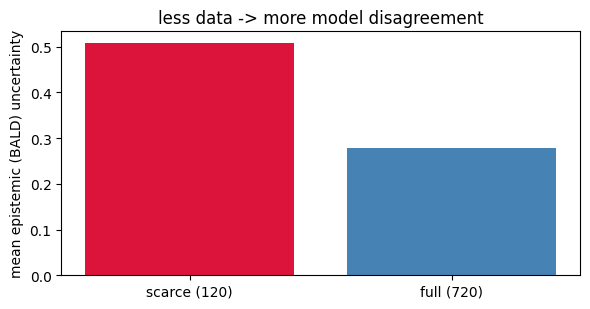

In [6]:
from mixle.stats import fit_knowledge_graph_ensemble

def ensemble_bald_and_accuracy(training):
    ens = fit_knowledge_graph_ensemble(training, nE, nR, dim=d, members=6, bootstrap=True,
                                       epochs=300, lr=1.0, rng=np.random.RandomState(0))
    bald = np.mean([ens.epistemic_tail_uncertainty(h, r) for h, r, t in test])
    acc = np.mean([ens.mean_tail_posterior(h, r).argmax() in true_of[(h, r)] for h, r, t in test])
    return bald, acc

single_acc = np.mean([kg.tail_log_posterior(h, r).argmax() in true_of[(h, r)] for h, r, t in test])
bald_full, acc_full = ensemble_bald_and_accuracy(train)
bald_scarce, acc_scarce = ensemble_bald_and_accuracy(train[:120])
print('single model tail accuracy = %.3f;  bagged ensemble = %.3f  (averaging helps)' % (single_acc, acc_full))
print('epistemic (BALD) uncertainty and accuracy by training-set size:')
print('  full data   (%4d facts): mean BALD = %.3f   accuracy = %.3f' % (len(train), bald_full, acc_full))
print('  scarce data (%4d facts): mean BALD = %.3f   accuracy = %.3f' % (120, bald_scarce, acc_scarce))
print('epistemic uncertainty rises when the data underdetermines the embeddings: it flags when a')
print('recommendation rests on too little evidence to trust, and more facts should be gathered first.')
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(['scarce (120)', 'full (%d)' % len(train)], [bald_scarce, bald_full], color=['crimson', 'steelblue'])
ax.set_ylabel('mean epistemic (BALD) uncertainty'); ax.set_title('less data -> more model disagreement')
plt.tight_layout(); plt.show()

## In short

- `KnowledgeGraphDistribution` is an ordinary `mixle.stats` distribution: fit it with
  `optimize(triples, KnowledgeGraphEstimator(...))`, score with `seq_log_density`, sample, like any model.
- It completes any slot (`complete` / `rank` / `tail_log_posterior`, `head_log_posterior`,
  `relation_log_posterior`), recommends missing facts (`recommend`) and missing subgraphs
  (`recommend_subgraph`), each ranked by model probability.
- Two uncertainties make the recommendations actionable: `ConformalKnowledgeGraph` gives a
  finite-sample-valid prediction set per completion (aleatoric, calibrated), and a
  `fit_knowledge_graph_ensemble` BALD score gives the epistemic uncertainty that flags which suggestions
  are underdetermined by the data.

## 7. Flexible subgraph patterns

The single-slot completions above are special cases of a general query: a subgraph pattern whose slots
are fixed ids or named variables (strings beginning with `?`), variables shared across edges.
`kg.pattern([...])` enumerates the variable bindings -- the completed subgraphs, with their missing parts
filled -- in descending joint plausibility using a best-first beam, so a chain, a star, or any
conjunctive motif is a single call. Variables can be restricted to candidate lists and already-present
motifs excluded. And because the pattern object exposes the same `log_density` / `enumerator` interface
as a structure distribution, it drops straight into `ConformalStructure` for a calibrated set of completed
subgraphs -- finite-sample coverage over the whole motif, not just one edge.

In [7]:
from mixle.ppl import ConformalStructure

h0 = test[0][0]
pat = kg.pattern([(h0, 0, '?x'), ('?x', 1, '?c')], beam=200)   # motif: (h0, r0, ?x), (?x, r1, ?c)
print('most plausible completions of the motif (%d, 0, ?x) and (?x, 1, ?c):' % h0)
for g, edges, score in pat.enumerate(top_n=5):
    print('  ?x=%2d ?c=%2d   %s   joint log-prob = %.2f' % (g['?x'], g['?c'], edges, score))

pat2 = kg.pattern([(h0, 0, '?x'), ('?x', 1, '?c')],
                  candidates={'?x': list(range(10)), '?c': list(range(10))}, known=observed, beam=200)
print('restricting ?x,?c to entities 0-9 and excluding already-present motifs leaves %d candidate subgraphs'
      % len(pat2.enumerate(top_n=None)))

# a conformal SET of completed subgraphs: calibrate the template (?a, ?r, ?x) on true facts
template = kg.pattern([('?a', '?r', '?x')])
inst = [template.binding({'?a': h, '?r': r, '?x': t}) for h, r, t in all_facts]
rng2 = np.random.RandomState(1); rng2.shuffle(inst)
cs = ConformalStructure(template, inst[:600], alpha=0.1)
print('conformal set of completed subgraphs: coverage on held-out true motifs = %.3f (target 0.90)'
      % cs.covers(inst[600:1200]).mean())

most plausible completions of the motif (23, 0, ?x) and (?x, 1, ?c):
  ?x=11 ?c= 5   [(23, 0, 11), (11, 1, 5)]   joint log-prob = -3.85
  ?x=26 ?c= 8   [(23, 0, 26), (26, 1, 8)]   joint log-prob = -4.23
  ?x= 3 ?c= 6   [(23, 0, 3), (3, 1, 6)]   joint log-prob = -4.25
  ?x=11 ?c= 6   [(23, 0, 11), (11, 1, 6)]   joint log-prob = -4.30
  ?x=11 ?c=30   [(23, 0, 11), (11, 1, 30)]   joint log-prob = -4.34
restricting ?x,?c to entities 0-9 and excluding already-present motifs leaves 97 candidate subgraphs
conformal set of completed subgraphs: coverage on held-out true motifs = 0.878 (target 0.90)


## References

- Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J. & Yakhnenko, O. (2013). Translating embeddings for modeling multi-relational data (TransE). NeurIPS.
- Yang, B., Yih, W., He, X., Gao, J. & Deng, L. (2015). Embedding entities and relations for learning and inference in knowledge bases (DistMult). ICLR.
- Vovk, V., Gammerman, A. & Shafer, G. (2005). Algorithmic Learning in a Random World. Springer. (conformal prediction)
- Houlsby, N., Huszar, F., Ghahramani, Z. & Lengyel, M. (2011). Bayesian active learning for classification (BALD / mutual-information uncertainty). https://arxiv.org/abs/1112.5745

## Exercises and extensions

1. Filtered ranking and rank-based metrics. Implement the standard filtered protocol (when ranking the
   tail of $(h, r, t)$, remove all other true tails of $(h, r)$ before ranking) and report mean
   reciprocal rank and Hits@$k$ for tail, head, and relation completion. Compare to the raw ranking.
2. Reciprocal relations. Augment the training triples with inverse relations $(t, r^{-1}, h)$ and refit;
   measure how much head completion improves and how the conformal head-set sizes shrink.
3. Adaptive conformal sets. Replace the $1 - p(\text{true})$ nonconformity with the adaptive APS score
   (cumulative probability of all candidates at least as likely as the true one) and compare set sizes at
   matched coverage across the three slots.
4. Epistemic-uncertainty active learning. Use the ensemble BALD score to pick the queries whose true
   facts, once revealed and added to training, most improve held-out completion accuracy, and compare to
   random acquisition.
5. Cold-start entities. Hold out all triples touching a subset of entities, then measure completion
   accuracy and conformal coverage on those unseen entities; discuss why coverage can still hold while
   accuracy collapses, and what exchangeability assumption is at stake.